# 01 EDA: Sparkov simulated transactions

**Purpose.** Understand the data well enough to motivate every feature in Phase 2, and to document honestly
how easy the task is.

**Test split is untouched.** This notebook loads only `train.parquet` and `valid.parquet`. The test split
(Oct-Dec 2020) is never opened here, so nothing learned in this notebook can be tuned on it.

**Colours.** Blue is legitimate or a single series, orange is fraud. The pair passes the colour validator
(CVD and normal-vision separation) on the light surface.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

from fraud.data.paths import PROCESSED_DIR
from fraud.params import load_params

params = load_params()
SEED = params["seed"]

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
LEGIT, FRAUD = "#2a78d6", "#eb6834"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK2,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.edgecolor": GRID,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "lines.linewidth": 2,
        "figure.dpi": 110,
        "legend.frameon": False,
    }
)
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.width = 160

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
valid = pd.read_parquet(PROCESSED_DIR / "valid.parquet")
df = pd.concat([train.assign(split="train"), valid.assign(split="valid")], ignore_index=True)


# Derived columns for exploration only. The production versions live in src/fraud/features (Phase 2).
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_ts"].dt.hour
df["weekday"] = df["trans_ts"].dt.dayofweek
df["month"] = df["trans_ts"].dt.to_period("M")
df["dist_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
df["age"] = (df["trans_ts"] - df["dob"]).dt.days / 365.25


def title(ax, text, sub=None):
    ax.set_title(text, pad=22 if sub else 6)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=9, color=INK2, va="bottom")


def pct(x):
    return f"{x:.2%}"


print("train/valid loaded; test not loaded.")

train/valid loaded; test not loaded.


## 1. Overview, quality and time coverage

In [2]:
summary = pd.DataFrame(
    {
        "rows": df.groupby("split").size(),
        "frauds": df.groupby("split")["is_fraud"].sum(),
        "fraud_rate": df.groupby("split")["is_fraud"].mean(),
        "cards": df.groupby("split")["card_id"].nunique(),
        "first": df.groupby("split")["trans_ts"].min(),
        "last": df.groupby("split")["trans_ts"].max(),
    }
)
display(summary)
print("null cells:", int(df.isna().sum().sum()))
print("exact duplicate rows:", int(df.drop(columns=["split", "month"]).duplicated().sum()))
print("cards seen in valid but never in train:", len(set(valid.card_id) - set(train.card_id)))
print("merchants seen in valid but never in train:", len(set(valid.merchant) - set(train.merchant)))
print(
    "imbalance (legit per fraud) in train:",
    round((1 - train.is_fraud.mean()) / train.is_fraud.mean(), 1),
)

,rows,frauds,fraud_rate,cards,first,last
split,,,,,,
train,1326733,7639,0.0058,984,2019-01-01 00:00:18,2020-06-30 23:59:50
valid,244140,1076,0.0044,917,2020-07-01 00:00:08,2020-09-30 23:59:23


null cells: 0


exact duplicate rows: 0


cards seen in valid but never in train: 9


merchants seen in valid but never in train: 0
imbalance (legit per fraud) in train: 172.7


days covered: 639 | days with zero transactions: 1
daily transactions: min 0 median 2291 max 6428
largest gap between consecutive transactions (all cards): 1 days 00:02:35


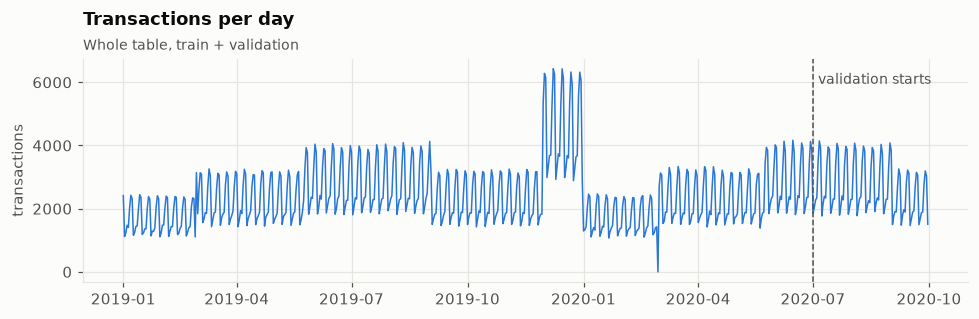

In [3]:
daily = df.set_index("trans_ts").resample("D")["is_fraud"].agg(["size", "sum"])
print(
    "days covered:", len(daily), "| days with zero transactions:", int((daily["size"] == 0).sum())
)
print(
    "daily transactions: min",
    int(daily["size"].min()),
    "median",
    int(daily["size"].median()),
    "max",
    int(daily["size"].max()),
)
gaps = df["trans_ts"].diff().dropna()
print("largest gap between consecutive transactions (all cards):", gaps.max())

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(daily.index, daily["size"], color=LEGIT, linewidth=1)
ax.axvline(pd.Timestamp("2020-07-01"), color=INK2, linestyle="--", linewidth=1)
ax.text(
    pd.Timestamp("2020-07-05"),
    daily["size"].max() * 0.98,
    "validation starts",
    color=INK2,
    fontsize=9,
    va="top",
)
title(ax, "Transactions per day", "Whole table, train + validation")
ax.set_ylabel("transactions")
plt.tight_layout()
plt.show()

## 2. Fraud rate over time, category, hour and weekday

month,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,...,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01
rate,0.96%,1.04%,0.70%,0.55%,0.56%,0.41%,0.38%,0.44%,0.59%,0.66%,...,0.42%,0.66%,0.70%,0.61%,0.45%,0.71%,0.53%,0.37%,0.47%,0.49%
frauds,506,517,494,376,408,354,331,382,418,454,...,592,343,336,444,302,527,467,321,415,340
n,52525,49866,70939,68078,72532,86064,86596,87359,70652,68758,...,141060,52202,47791,72850,66892,74343,87805,85848,88759,69533


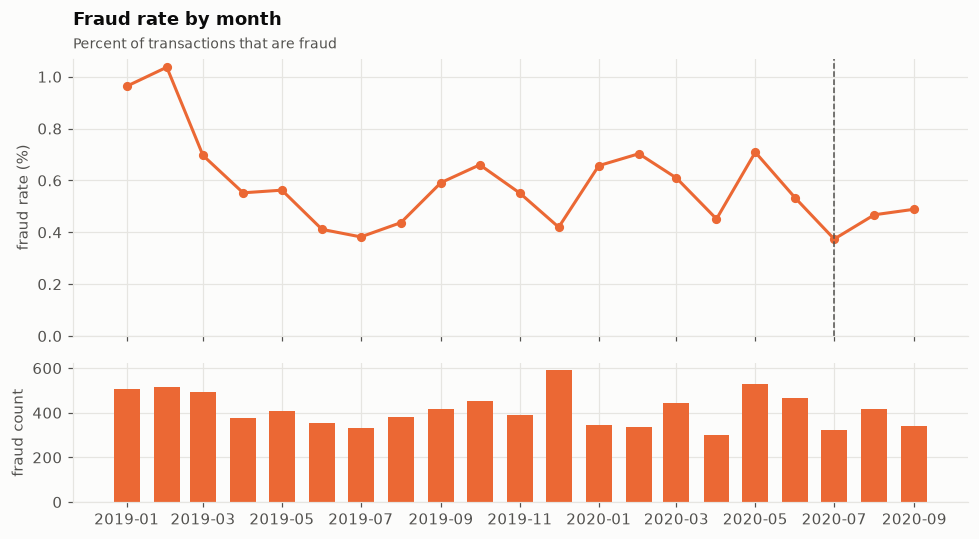

In [4]:
m = df.groupby("month").agg(
    rate=("is_fraud", "mean"), frauds=("is_fraud", "sum"), n=("is_fraud", "size")
)
m.index = m.index.to_timestamp()
display(m.assign(rate=m["rate"].map(pct)).T)

fig, (a1, a2) = plt.subplots(
    2, 1, figsize=(9, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
a1.plot(m.index, m["rate"] * 100, color=FRAUD, marker="o", markersize=5)
a1.axvline(pd.Timestamp("2020-07-01"), color=INK2, linestyle="--", linewidth=1)
title(a1, "Fraud rate by month", "Percent of transactions that are fraud")
a1.set_ylabel("fraud rate (%)")
a1.set_ylim(bottom=0)
a2.bar(m.index, m["frauds"], width=20, color=FRAUD)
a2.set_ylabel("fraud count")
plt.tight_layout()
plt.show()

,rate,frauds,n,share_of_frauds
category,,,,
shopping_net,1.68%,1991,118328,22.85%
misc_net,1.39%,1066,76694,12.23%
grocery_pos,1.34%,2010,149493,23.06%
shopping_pos,0.69%,967,141047,11.10%
gas_transport,0.43%,691,159400,7.93%
misc_pos,0.30%,291,96862,3.34%
travel,0.29%,141,49208,1.62%
grocery_net,0.28%,155,54895,1.78%
entertainment,0.24%,276,113716,3.17%


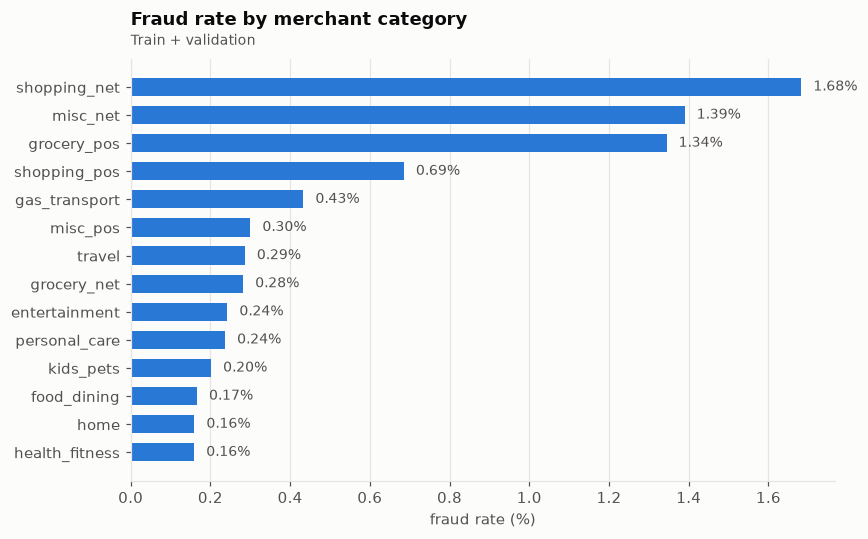

In [5]:
c = df.groupby("category").agg(
    rate=("is_fraud", "mean"), frauds=("is_fraud", "sum"), n=("is_fraud", "size")
)
c["share_of_frauds"] = c["frauds"] / c["frauds"].sum()
c = c.sort_values("rate")
shown = c.sort_values("rate", ascending=False)
display(
    shown.assign(rate=shown["rate"].map(pct), share_of_frauds=shown["share_of_frauds"].map(pct))
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(c.index, c["rate"] * 100, color=LEGIT, height=0.65)
for y, v in enumerate(c["rate"] * 100):
    ax.text(v + 0.03, y, f"{v:.2f}%", va="center", fontsize=9, color=INK2)
ax.grid(axis="y", visible=False)
title(ax, "Fraud rate by merchant category", "Train + validation")
ax.set_xlabel("fraud rate (%)")
plt.tight_layout()
plt.show()

share of all frauds between 22:00 and 03:59: 84.78%
share of all transactions between 22:00 and 03:59: 23.50%
fraud rate 22:00-03:59: 2.00% | other hours: 0.11%


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
mean,0.44%,0.53%,0.64%,0.67%,0.68%,0.59%,0.47%
sum,1379,1149,1002,1171,1244,1359,1411


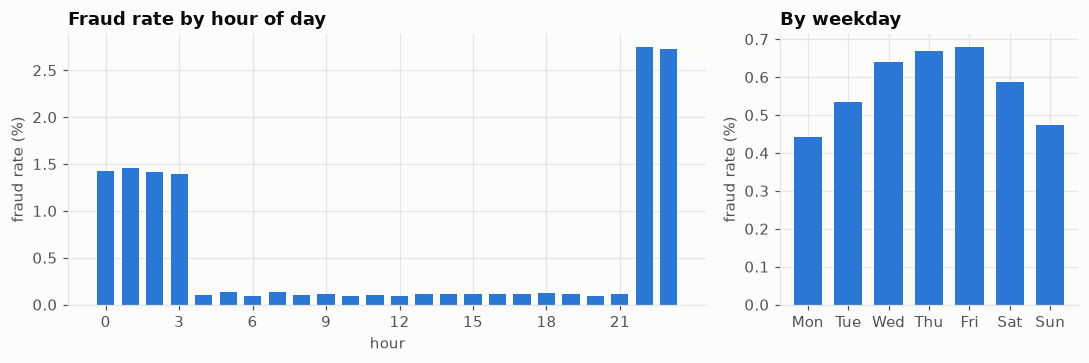

In [6]:
h = df.groupby("hour")["is_fraud"].agg(["mean", "sum"])
w = df.groupby("weekday")["is_fraud"].agg(["mean", "sum"])
w.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
night = [22, 23, 0, 1, 2, 3]
print(
    "share of all frauds between 22:00 and 03:59:",
    pct(df.loc[df.hour.isin(night), "is_fraud"].sum() / df.is_fraud.sum()),
)
print("share of all transactions between 22:00 and 03:59:", pct(df.hour.isin(night).mean()))
print(
    "fraud rate 22:00-03:59:",
    pct(df.loc[df.hour.isin(night), "is_fraud"].mean()),
    "| other hours:",
    pct(df.loc[~df.hour.isin(night), "is_fraud"].mean()),
)
display(w.assign(mean=w["mean"].map(pct)).T)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [3, 1.4]})
a1.bar(h.index, h["mean"] * 100, color=LEGIT, width=0.7)
title(a1, "Fraud rate by hour of day")
a1.set_xlabel("hour")
a1.set_ylabel("fraud rate (%)")
a1.set_xticks(range(0, 24, 3))
a2.bar(w.index, w["mean"] * 100, color=LEGIT, width=0.7)
title(a2, "By weekday")
a2.set_ylabel("fraud rate (%)")
plt.tight_layout()
plt.show()

## 3. Amount: fraud vs legitimate

,count,mean,std,min,10%,50%,90%,max
is_fraud,,,,,,,,
legit,"1,562,158.0000",67.6328,152.4465,1.0000,4.0900,47.2500,134.1400,"28,948.9000"
fraud,"8,715.0000",531.4423,390.6187,1.0600,12.1940,398.8200,"1,025.5020","1,376.0400"


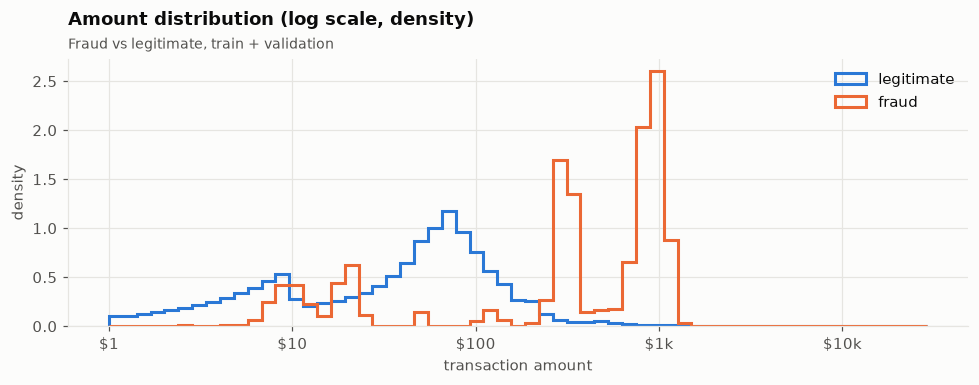

In [7]:
q = (
    df.groupby("is_fraud")["amt"]
    .describe(percentiles=[0.1, 0.5, 0.9])
    .rename(index={0: "legit", 1: "fraud"})
)
display(q)

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, np.log10(df["amt"].max()), 60)
for flag, colour, label in [(0, LEGIT, "legitimate"), (1, FRAUD, "fraud")]:
    ax.hist(
        np.log10(df.loc[df.is_fraud == flag, "amt"]),
        bins=bins,
        density=True,
        histtype="step",
        color=colour,
        linewidth=2,
        label=label,
    )
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(["$1", "$10", "$100", "$1k", "$10k"])
title(ax, "Amount distribution (log scale, density)", "Fraud vs legitimate, train + validation")
ax.set_xlabel("transaction amount")
ax.set_ylabel("density")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

,mean,sum,size
amt,,,
"(0.0, 10.0]",0.15%,602,407113
"(10.0, 25.0]",0.77%,1195,154703
"(25.0, 50.0]",0.02%,63,253140
"(50.0, 100.0]",0.01%,54,471607
"(100.0, 200.0]",0.09%,183,209897
"(200.0, 300.0]",2.39%,910,38063
"(300.0, 500.0]",8.34%,1470,17623
"(500.0, 1000.0]",22.39%,3133,13990
"(1000.0, inf]",23.33%,1105,4737


is_fraud,legit,fraud
category,,
misc_pos,13.9700,9.1000
travel,6.2200,9.7500
gas_transport,62.9500,10.6900
grocery_net,50.9900,12.2000
kids_pets,47.2200,19.5900
health_fitness,42.9000,19.8100
personal_care,32.7700,20.9100
food_dining,41.9700,119.7200
home,48.1600,253.3850


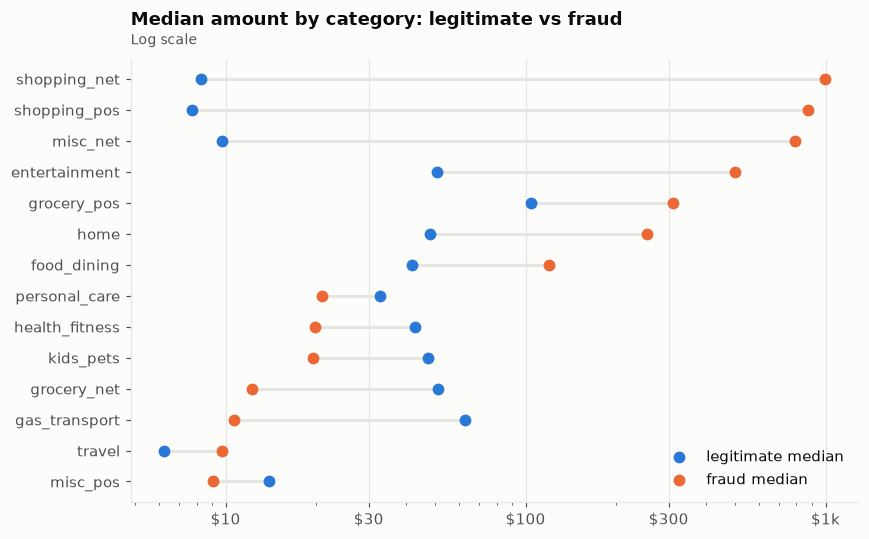

In [8]:
bins = [0, 10, 25, 50, 100, 200, 300, 500, 1000, np.inf]
b = df.groupby(pd.cut(df["amt"], bins), observed=True)["is_fraud"].agg(["mean", "sum", "size"])
b.index = b.index.astype(str)
display(b.assign(mean=b["mean"].map(pct)))

med = (
    df.groupby(["category", "is_fraud"])["amt"]
    .median()
    .unstack()
    .rename(columns={0: "legit", 1: "fraud"})
    .sort_values("fraud")
)
display(med)
fig, ax = plt.subplots(figsize=(8, 5))
for y, (cat, row) in enumerate(med.iterrows()):
    ax.plot([row["legit"], row["fraud"]], [y, y], color=GRID, linewidth=2, zorder=1)
ax.scatter(med["legit"], range(len(med)), color=LEGIT, s=45, zorder=2, label="legitimate median")
ax.scatter(med["fraud"], range(len(med)), color=FRAUD, s=45, zorder=2, label="fraud median")
ax.set_yticks(range(len(med)))
ax.set_yticklabels(med.index)
ax.set_xscale("log")
ax.set_xticks([10, 30, 100, 300, 1000])
ax.set_xticklabels(["$10", "$30", "$100", "$300", "$1k"])
ax.grid(axis="y", visible=False)
title(ax, "Median amount by category: legitimate vs fraud", "Log scale")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Customer, merchant distance and city size

                  count    mean     std    min     25%     50%     75%      max
is_fraud                                                                       
legit    1,562,158.0000 76.1161 29.1163 0.0223 55.3350 78.2306 98.5065 152.1172
fraud        8,715.0000 76.1781 28.7595 0.7388 55.5240 77.9764 98.3398 144.5224


fraud rate by gender: {'F': '0.51%', 'M': '0.60%'}


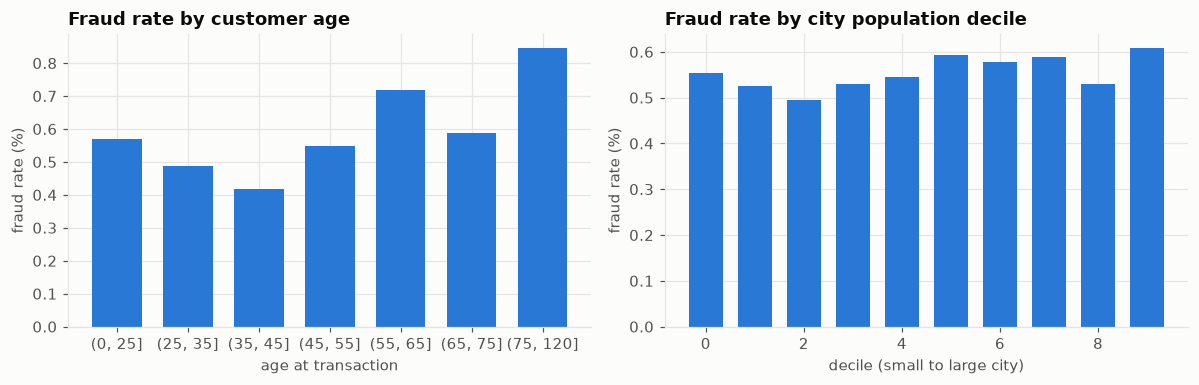

age,"(0, 25]","(25, 35]","(35, 45]","(45, 55]","(55, 65]","(65, 75]","(75, 120]"
mean,0.57%,0.49%,0.42%,0.55%,0.72%,0.59%,0.85%
sum,827,1672,1383,1715,1421,733,964
size,145560,343583,332116,313307,197877,124424,114006


,22-260,260-566,566-964,"964-1,631","1,631-2,456","2,456-4,677","4,677-9,993","9,993-42,384","42,384-186,140","186,140-2,906,700"
mean,0.55%,0.53%,0.49%,0.53%,0.55%,0.59%,0.58%,0.59%,0.53%,0.61%
sum,876,823,788,832,858,920,908,925,839,946
size,158002,156531,159205,156903,157182,154862,157260,157161,158227,155540


In [9]:
print(df.groupby("is_fraud")["dist_km"].describe().rename(index={0: "legit", 1: "fraud"}))

age_bins = [0, 25, 35, 45, 55, 65, 75, 120]
a = df.groupby(pd.cut(df["age"], age_bins), observed=True)["is_fraud"].agg(["mean", "sum", "size"])
a.index = a.index.astype(str)
pop = df.groupby(pd.qcut(df["city_pop"], 10, duplicates="drop"), observed=True)["is_fraud"].agg(
    ["mean", "sum", "size"]
)
pop.index = [f"{int(i.left):,}-{int(i.right):,}" for i in pop.index]
g = df.groupby("gender")["is_fraud"].mean()
print("fraud rate by gender:", g.map(pct).to_dict())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.bar(a.index, a["mean"] * 100, color=LEGIT, width=0.7)
title(a1, "Fraud rate by customer age")
a1.set_ylabel("fraud rate (%)")
a1.set_xlabel("age at transaction")
a2.bar(range(len(pop)), pop["mean"] * 100, color=LEGIT, width=0.7)
title(a2, "Fraud rate by city population decile")
a2.set_xlabel("decile (small to large city)")
a2.set_ylabel("fraud rate (%)")
plt.tight_layout()
plt.show()
display(a.assign(mean=a["mean"].map(pct)).T)
display(pop.assign(mean=pop["mean"].map(pct)).T)

## 5. Fraud clusters within a card

cards: 993 | cards with at least one fraud: 883
frauds per fraud-affected card: median 10.0 max 19
share of frauds whose previous transaction on the same card is also fraud: 89.86%
base rate that a transaction follows a fraud (all rows): 0.55%
median hours since previous card transaction  legit: 4.55 | fraud: 1.36


fraud bursts: 910 | median frauds per burst: 10.0 | median span (h): 45.01


count   910.0000
mean      9.5769
std       3.3138
min       1.0000
25%       8.0000
50%      10.0000
75%      12.0000
max      19.0000
Name: size, dtype: float64

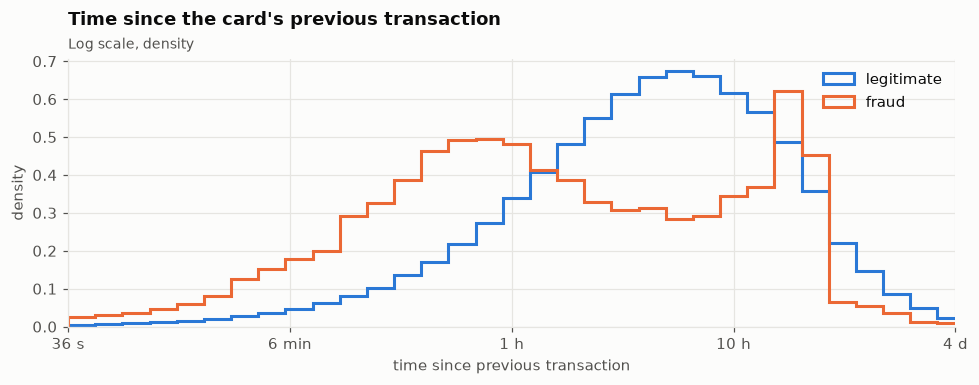

In [10]:
d = df.sort_values(["card_id", "trans_ts"], kind="stable").copy()
d["gap_h"] = d.groupby("card_id")["trans_ts"].diff().dt.total_seconds() / 3600
d["prev_fraud"] = d.groupby("card_id")["is_fraud"].shift(1)

per_card = d.groupby("card_id")["is_fraud"].agg(["sum", "size"])
print("cards:", len(per_card), "| cards with at least one fraud:", int((per_card["sum"] > 0).sum()))
print(
    "frauds per fraud-affected card: median",
    per_card.loc[per_card["sum"] > 0, "sum"].median(),
    "max",
    int(per_card["sum"].max()),
)
f = d[d.is_fraud == 1]
print(
    "share of frauds whose previous transaction on the same card is also fraud:",
    pct((f["prev_fraud"] == 1).mean()),
)
print(
    "base rate that a transaction follows a fraud (all rows):", pct((d["prev_fraud"] == 1).mean())
)
print(
    "median hours since previous card transaction  legit:",
    round(d.loc[d.is_fraud == 0, "gap_h"].median(), 2),
    "| fraud:",
    round(f["gap_h"].median(), 2),
)

# Fraud "episodes": consecutive frauds on a card within 24h form one burst.
f = f.sort_values(["card_id", "trans_ts"])
new_burst = (f["card_id"] != f["card_id"].shift()) | (f["trans_ts"].diff() > pd.Timedelta(hours=24))
f = f.assign(burst=new_burst.cumsum())
bursts = f.groupby("burst").agg(
    size=("is_fraud", "size"),
    span_h=("trans_ts", lambda s: (s.max() - s.min()).total_seconds() / 3600),
)
print(
    "fraud bursts:",
    len(bursts),
    "| median frauds per burst:",
    bursts["size"].median(),
    "| median span (h):",
    round(bursts["span_h"].median(), 2),
)
display(bursts["size"].describe())

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(-2, 4, 50)
for flag, colour in [(0, LEGIT), (1, FRAUD)]:
    x = np.log10(d.loc[(d.is_fraud == flag) & (d.gap_h > 0), "gap_h"])
    ax.hist(
        x,
        bins=bins,
        density=True,
        histtype="step",
        color=colour,
        linewidth=2,
        label="fraud" if flag else "legitimate",
    )
ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_xticklabels(["36 s", "6 min", "1 h", "10 h", "4 d"])
ax.set_xlim(-2, 2)
title(ax, "Time since the card's previous transaction", "Log scale, density")
ax.set_xlabel("time since previous transaction")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Is the simulator making this too easy? Single-feature diagnostics

In [11]:
# Diagnostics only. Encoders are fitted on train and scored on validation; nothing here is a model we ship.
tr, va = df[df.split == "train"], df[df.split == "valid"]
rows = []
for col in ["amt", "hour", "dist_km", "age", "city_pop", "weekday"]:
    auc = roc_auc_score(va["is_fraud"], va[col])
    rows.append(
        (
            col,
            max(auc, 1 - auc),
            average_precision_score(va["is_fraud"], va[col] if auc >= 0.5 else -va[col]),
        )
    )
for col in ["category", "merchant", "job", "state"]:
    enc = tr.groupby(col)["is_fraud"].mean()
    score = va[col].map(enc).astype(float).fillna(tr["is_fraud"].mean())
    rows.append(
        (
            col + " (train fraud rate)",
            roc_auc_score(va["is_fraud"], score),
            average_precision_score(va["is_fraud"], score),
        )
    )
uni = (
    pd.DataFrame(rows, columns=["feature", "valid_roc_auc", "valid_avg_precision"])
    .set_index("feature")
    .sort_values("valid_roc_auc", ascending=False)
)
print("valid fraud rate (average-precision chance level):", pct(va.is_fraud.mean()))
display(uni)

cats = tr["category"].astype("category").cat.categories


def design(part):
    return pd.DataFrame(
        {
            "amt": part["amt"],
            "hour": part["hour"],
            "dist_km": part["dist_km"],
            "age": part["age"],
            "cat": pd.Categorical(part["category"], categories=cats).codes,
        }
    )


tree = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(design(tr), tr["is_fraud"])
p = tree.predict_proba(design(va))[:, 1]
print(
    "depth-5 tree on amt/hour/dist/age/category -> valid ROC AUC:",
    round(roc_auc_score(va.is_fraud, p), 4),
    "| avg precision:",
    round(average_precision_score(va.is_fraud, p), 4),
)

valid fraud rate (average-precision chance level): 0.44%


,valid_roc_auc,valid_avg_precision
feature,,
amt,0.8368,0.1533
category (train fraud rate),0.7127,0.0100
merchant (train fraud rate),0.7035,0.0102
hour,0.5822,0.0133
city_pop,0.5376,0.0046
age,0.5291,0.0059
weekday,0.5267,0.0046
dist_km,0.5046,0.0045
state (train fraud rate),0.4731,0.0041


depth-5 tree on amt/hour/dist/age/category -> valid ROC AUC: 0.9596 | avg precision: 0.6747


In [12]:
# Simulator fingerprints: where exactly does fraud live?
fr = df[df.is_fraud == 1]
share = (fr["hour"].value_counts(normalize=True).sort_index() * 100).round(2)
print("share of frauds by hour (%):", share.to_dict())
empty = daily.index[daily["size"] == 0]
print("days with no transactions at all:", [str(x.date()) for x in empty])
print(
    "largest fraud amount:",
    fr["amt"].max(),
    "| legitimate transactions above that:",
    int(((df.is_fraud == 0) & (df["amt"] > fr["amt"].max())).sum()),
)
small, mid, big = fr[fr.amt < 50], fr[(fr.amt >= 50) & (fr.amt < 200)], fr[fr.amt >= 200]
print(
    "fraud counts by amount band  <$50:", len(small), "| $50-200:", len(mid), "| >=$200:", len(big)
)
print("top categories of <$50 fraud:", small["category"].value_counts().head(6).to_dict())
print("top categories of >=$200 fraud:", big["category"].value_counts().head(6).to_dict())
night, high = df.hour.isin([22, 23, 0, 1, 2, 3]), df["amt"] >= 200
rule = df[night & high]
print(
    "hand rule (22:00-03:59 and amount >= $200): precision",
    round(rule.is_fraud.mean(), 3),
    "| recall",
    round(rule.is_fraud.sum() / df.is_fraud.sum(), 3),
)

share of frauds by hour (%): {0: 8.43, 1: 8.67, 2: 8.38, 3: 8.27, 4: 0.62, 5: 0.77, 6: 0.56, 7: 0.78, 8: 0.62, 9: 0.64, 10: 0.55, 11: 0.61, 12: 0.88, 13: 1.0, 14: 1.07, 15: 1.03, 16: 1.0, 17: 1.02, 18: 1.11, 19: 1.08, 20: 0.86, 21: 1.01, 22: 25.57, 23: 25.46}
days with no transactions at all: ['2020-02-29']
largest fraud amount: 1376.04 | legitimate transactions above that: 1932
fraud counts by amount band  <$50: 1860 | $50-200: 237 | >=$200: 6618
top categories of <$50 fraud: {'gas_transport': 691, 'kids_pets': 277, 'personal_care': 237, 'misc_pos': 193, 'health_fitness': 166, 'grocery_net': 155}
top categories of >=$200 fraud: {'grocery_pos': 2010, 'shopping_net': 1991, 'misc_net': 1066, 'shopping_pos': 967, 'entertainment': 276, 'home': 232}
hand rule (22:00-03:59 and amount >= $200): precision 0.26 | recall 0.645


## 7. Conclusions

Numbers below are from the executed cells above (train and validation only).

**Data quality**
- No nulls, no duplicate rows, no unseen merchants in validation. 9 validation cards never appear in train.
- Time coverage is complete except one empty day: **2020-02-29** has no transactions at all (apparently a simulator quirk around the leap day). The largest gap between consecutive transactions is just over one day, which is that empty day.
- While cleaning, we also found that the raw `unix_time` column is the transaction timestamp shifted back exactly 7 years, so it is dropped (see the data card).

**Class balance and time**
- Fraud is rare: 0.58% in train (about 173 legitimate per fraud) and 0.44% in validation. Monthly rates swing between 0.37% and 1.04% with no clean trend.
- Fraud arrives in bursts per card (below), so the month-to-month rate is noisy. Precision at a fixed threshold depends on prevalence, so the precision budget must be checked on the split it is set on, and prevalence can differ between splits.

**Signals worth building features for**
- **Hour of day is the strongest single pattern.** 84.8% of frauds happen between 22:00 and 03:59, a window holding 23.5% of all transactions. The fraud rate is 2.00% inside it and 0.11% outside. Hours 22 and 23 alone hold about half of all frauds.
- **Amount** (validation ROC AUC 0.84 on its own). Fraud median is $399 vs $47 for legitimate. Fraud clusters in two bands: under $50 (1,860 frauds) and $200 and above (6,618), with only 237 between $50 and $200.
- **Category:** shopping_net (1.68%), misc_net (1.39%) and grocery_pos (1.34%) hold 58% of frauds. Amount and category interact: in shopping_net, misc_net and shopping_pos the median fraud is $800-1,000 against $8-10 legitimate, while in gas_transport fraud is small ($11 vs $63). A model needs amount relative to category, not amount alone.
- **Time since the card's previous transaction:** median 1.36 h for fraud vs 4.55 h for legitimate.

**Weak or no signal**
- **Customer-merchant distance carries no signal here:** the distributions are identical (mean 76 km for both, ROC AUC 0.50). Merchants are simulated within about 150 km of the customer.
- City population is flat (0.49-0.61% across deciles). Age (0.42-0.85%), weekday (0.44-0.68%) and gender (F 0.51% vs M 0.60%) are mild at best.
- Target rates for `job` and `state` do not generalise to validation (ROC AUC 0.29 and 0.47), so high-cardinality encodings are noise or harm here. `merchant` scores 0.70 but adds little over `category`.

**Fraud clusters within a card**
- 883 of 993 cards have at least one fraud. Frauds come in bursts of a median 10 (910 bursts, median span 45 h).
- 89.9% of frauds directly follow another fraud on the same card, against a 0.55% base rate. Fraud labels are not known when a transaction is scored, so this cannot be used as a feature. It is, however, the reason random splits would leak, and it motivates velocity features built only from transaction history (Phase 2, v2 pipeline).

**Is it too easy? Yes.**
- A depth-5 decision tree on five raw columns (amount, hour, distance, age, category) reaches validation ROC AUC 0.96 and average precision 0.67, against a 0.44% chance level. A hand rule (22:00-03:59 and amount of $200 or more) alone gives precision 0.26 at recall 0.65.
- The fingerprints are hard-coded simulator behaviour: a night window, category-dependent amount bands, and a fraud amount ceiling of $1,376 above which 1,932 legitimate transactions sit. Expect high metrics, and report them with that caveat in the README and model card. The ULB benchmark in Phase 7 is the realism check.

**Consequences for Phase 2**
1. Build: log amount, hour with a night-window flag, category, weekday, amount relative to category (fitted on train only), and, in v2, time since previous transaction and per-card velocity.
2. Distance: implement it as planned but treat it as a candidate to drop after an ablation shows no lift.
3. Do not target-encode `job`, `state` or `merchant` unless cross-fitting shows real lift.
4. Time-based splits are confirmed as necessary, and the precision >= 0.50 budget looks reachable on validation given the tree's average precision of 0.67 (to be measured properly in Phase 3).